In [1]:
from fears.utils import AutoRate
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy import stats
from sklearn.linear_model import LinearRegression
import pandas as pd
import pickle
from scipy.optimize import curve_fit

In [2]:
od_file = '../calibration_data/cfu_assay_8312026/JC_OD600_96w_20260829_091351_S.xlsx'

p_od = AutoRate.Plate(od_file,mode='single_measurement')
od_data = p_od.od_data_to_dict(p_od.data)

# col 11 is background

rows = ['D','E','F','G']
cols = ['2','3','4','5','6','7','8','9','10']

bg_est = np.mean([od_data[r+'11'] for r in rows])

od_mean = []
od_err = []
od_std = []

# subtract bg_est from all values in od_data
od_data = {k: v - bg_est for k, v in od_data.items()}

for col in cols:
    od_mean.append(np.mean([od_data[r+col] for r in rows]))
    od_err.append(np.std([od_data[r+col] for r in rows])/np.sqrt(len(rows)))
    od_std.append(np.std([od_data[r+col] for r in rows]))

# od_mean = od_mean - bg_est

od_mean = np.array(od_mean)
od_err = np.array(od_err)
od_std = np.array(od_std)

In [3]:
ab_file = '../calibration_data/cfu_assay_8312026/JC_FLUO_96w_20260829_100044_S.xlsx'

p_ab = AutoRate.Plate(ab_file,mode='single_measurement')
ab_data = p_ab.od_data_to_dict(p_ab.data)

rows = ['D','E','F','G']

ab_background = np.mean([ab_data[r+'11'] for r in rows])
ab_bg_est = np.mean([ab_data[r+'11'] for r in rows])
ab_bg_std = np.std([ab_data[r+'11'] for r in rows])
ab_bg_mean = np.mean([ab_data[r+'11'] for r in rows])

ab_mean = []
ab_err = []
ab_std = []

# subtract ab_background from all values in ab_data
# ab_data = {k: v - ab_background for k, v in ab_data.items()}

for col in cols:
    ab_mean.append(np.mean([ab_data[r+col] for r in rows]))
    ab_err.append(np.std([ab_data[r+col] for r in rows])/np.sqrt(len(rows)))
    ab_std.append(np.std([ab_data[r+col] for r in rows]))
    
# ab_mean = np.array(ab_mean) - ab_background

ab_mean = np.array(ab_mean)
ab_err = np.array(ab_err)
ab_std = np.array(ab_std)



In [4]:
cfu_file = '../calibration_data/cfu_assay_8312026/colony_counts_S_aureus.xlsx'

cfu_data = pd.read_excel(cfu_file, sheet_name='Sheet1')

# set ['experiment'] column to 'high_density' for all rows
cfu_data['experiment'] = 'high_density'

cfu_lwrb_file = '../calibration_data/cfu_assay_8312026/colony_counts_S_aureus_LWRB.xlsx'

cfu_lwrb = pd.read_excel(cfu_lwrb_file)

# remove 'Plate ID' from column names
cfu_lwrb.drop(columns=['Plate ID'], inplace=True)

# set ['experiment'] column to 'low_density' for all rows
cfu_lwrb['experiment'] = 'low_density'

# append cfu_lwrb to cfu_data
cfu_data = pd.concat([cfu_data, cfu_lwrb], ignore_index=True)

# convert rows B and C to cfu/mL
cfu_data['dilution_factor'] = cfu_data['subsequent_dilution'] / cfu_data['vol']
cfu_data['B_raw_counts'] = cfu_data['B']
cfu_data['C_raw_counts'] = cfu_data['C']
cfu_data['B'] = cfu_data['B'] * cfu_data['dilution_factor']
cfu_data['C'] = cfu_data['C'] * cfu_data['dilution_factor']
cfu_data['mean'] = cfu_data[['B','C']].mean(axis=1)
cfu_data['mean_raw'] = cfu_data[['B_raw_counts','C_raw_counts']].mean(axis=1)   

Text(0.5, 0, 'Column')

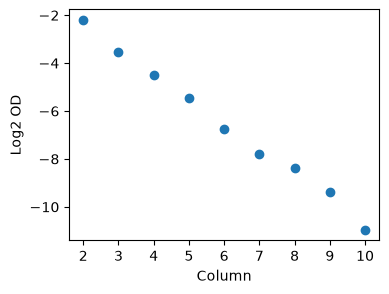

In [5]:
# plot od vs dilution

fig,ax = plt.subplots(figsize=(4,3))

od_mean_log2 = np.log2(od_mean)

ax.scatter(cols,od_mean_log2)
ax.set_ylabel('Log2 OD')
ax.set_xlabel('Column')

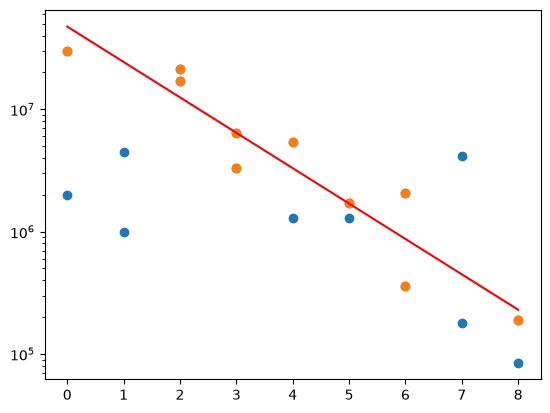

In [6]:
# make a cfu data table long

cfu_long = cfu_data.melt(
    id_vars=['initial_dilution', 'subsequent_dilution', 'vol',
       'expected_colonies', 'experiment', 'dilution_factor','Column'], 
    value_vars = ['B_raw_counts','C_raw_counts'],
    var_name = 'replicate',
    value_name = 'raw_counts'
)

cfu_long = cfu_long[cfu_long['experiment'] == 'high_density' ]

cfu_long['cfu'] = cfu_long['raw_counts'] * cfu_long['dilution_factor']

cfu_long['log2_dilution'] = np.log2(cfu_long['initial_dilution'])

# filter out rows for which raw_counts < 30 or > 300

# cfu_filt = cfu_long[(cfu_long['raw_counts'] >= 30) & (cfu_long['raw_counts'] <= 300)]
filt_indx = (cfu_long['raw_counts'] >= 30) & (cfu_long['raw_counts'] <= 300)

fig,ax = plt.subplots()

ax.scatter(cfu_long['log2_dilution'],cfu_long['cfu'])
ax.scatter(cfu_long['log2_dilution'][filt_indx],cfu_long['cfu'][filt_indx])

ydata = np.log10(cfu_long['cfu'][filt_indx])
xdata = np.array(cfu_long['log2_dilution'][filt_indx])

reg = LinearRegression().fit(xdata.reshape(-1, 1), ydata)

xplot = np.linspace(xdata.min(), xdata.max(), 100)

ax.set_yscale('log')
ax.plot(xplot, 10**reg.predict(xplot.reshape(-1, 1)), color='red')

cfu_filt = cfu_long[filt_indx]


/var/folders/zc/70qypfn92xg4qzzd0ldt5ks80000gn/T/ipykernel_55646/1242759251.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cfu_filt['Column'] = cfu_filt['Column'].astype(int)


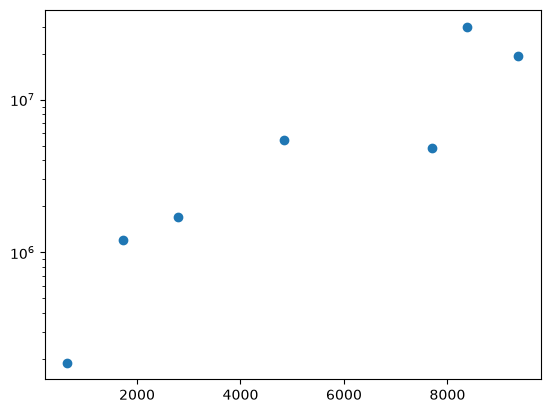

In [7]:
# plot AB against CFU

# for each column that we have data for, generate a cfu estimate

cols = [2, 3, 4, 5, 6, 7, 8, 9, 10]

cols_plot =[]
cfu_est = []
ab_plot = []
ab_err_plot = []

# convert 'Column' to int
cfu_filt['Column'] = cfu_filt['Column'].astype(int)

i = 0
for col in cols:
    if col in cfu_filt['Column'].values:
        cols_plot.append(col)
        cfu_est.append(cfu_filt.loc[cfu_filt['Column'] == col, 'cfu'].mean())
        ab_plot.append(ab_mean[i])
        ab_err_plot.append(ab_err[i])
    i+=1


fig,ax = plt.subplots()
ax.errorbar(ab_plot, cfu_est, yerr=ab_err_plot, fmt='o')
ax.set_yscale('log')


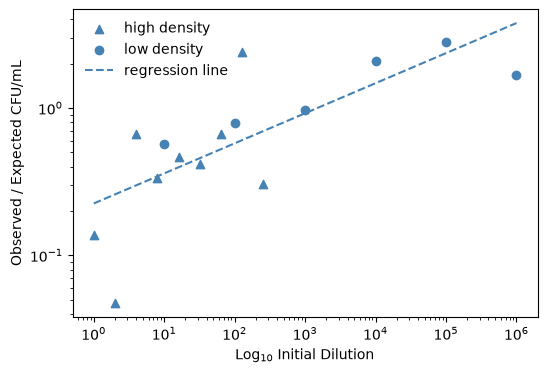

In [8]:
# plot observed vs expected CFU/mL

fig,ax = plt.subplots(figsize=(6,4))

# make high density points triangles and low density points circles
high_density = cfu_data[cfu_data['experiment'] == 'high_density']
low_density = cfu_data[cfu_data['experiment'] == 'low_density']

ax.scatter(high_density['initial_dilution'], high_density['mean_raw']/high_density['expected_colonies'],
           color='steelblue', marker='^',label='high density')
ax.scatter(low_density['initial_dilution'], low_density['mean_raw']/low_density['expected_colonies'], 
           color='steelblue', marker='o',label='low density')

# get linear regression

y_data = cfu_data['mean_raw']/cfu_data['expected_colonies']
x_data = cfu_data['initial_dilution']

reg = LinearRegression().fit(np.log10(x_data).values.reshape(-1,1), np.log10(y_data).values.reshape(-1,1))

# plot regression line

x_plot = [np.min(x_data), np.max(x_data)]
y_plot = 10**(reg.intercept_ + reg.coef_ * np.log10(x_plot))

ax.plot(x_plot, y_plot.flatten(), '--', color='steelblue',label='regression line')

ax.set_xscale('log')
ax.set_yscale('log')

# ax.set_ylim([0.5,2])

ax.set_ylabel('Observed / Expected CFU/mL')
ax.set_xlabel('Log$_{10}$ Initial Dilution')

ax.legend(frameon=False, loc='best', fontsize=10)

In [9]:
cols = ['2','3','4','5','6','7','8','9','10']

# compute lowest RFU statistically different from background (mean + 3*std)
cfu_hd = cfu_data[cfu_data['experiment'] == 'high_density']
# calculate cfu_hd mean and std with samples B and C
cfu_hd_mean = cfu_hd[['B','C']].mean(axis=1)
cfu_hd_std = cfu_hd[['B','C']].std(axis=1)

ab_background_arr = np.array([ab_data[r+'11'] for r in rows])
pvalues = []

for col in cols:
    ab_col_arr = np.array([ab_data[r+col] for r in rows])
    t_stat, p_val = stats.ttest_ind(ab_col_arr, ab_background_arr, equal_var=False)
    pvalues.append(p_val)

# find the lowest RFU value for which p-value < 0.05

llq = np.min([ab_mean[i] for i in range(len(ab_mean)) if pvalues[i] < 0.05])

# compute ULQ (highest RFU value for which RFU and CFU increase)

ab_mean_t = np.flip(ab_mean)
cfu_hd_mean_t = np.flip(cfu_hd_mean.values)

for i in range(len(ab_mean_t)-1):
    if ab_mean_t[i+1] < ab_mean_t[i]:
        ulq = ab_mean_t[i]
        break
    else:
        if cfu_hd_mean_t[i+1] < cfu_hd_mean_t[i]:
            ulq = ab_mean_t[i]
            break

print(llq)
print(ulq)

651.75
1026.5


/var/folders/zc/70qypfn92xg4qzzd0ldt5ks80000gn/T/ipykernel_55646/1242759251.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cfu_filt['Column'] = cfu_filt['Column'].astype(int)


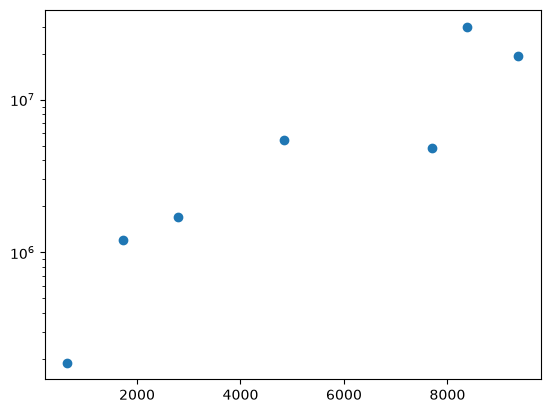

In [10]:
# plot AB against CFU

# for each column that we have data for, generate a cfu estimate

cols = [2, 3, 4, 5, 6, 7, 8, 9, 10]

cols_plot =[]
cfu_est = []
ab_plot = []
ab_err_plot = []

# convert 'Column' to int
cfu_filt['Column'] = cfu_filt['Column'].astype(int)

i = 0
for col in cols:
    if col in cfu_filt['Column'].values:
        cols_plot.append(col)
        cfu_est.append(cfu_filt.loc[cfu_filt['Column'] == col, 'cfu'].mean())
        ab_plot.append(ab_mean[i])
        ab_err_plot.append(ab_err[i])
    i+=1


fig,ax = plt.subplots()
ax.errorbar(ab_plot, cfu_est, yerr=ab_err_plot, fmt='o')
ax.set_yscale('log')


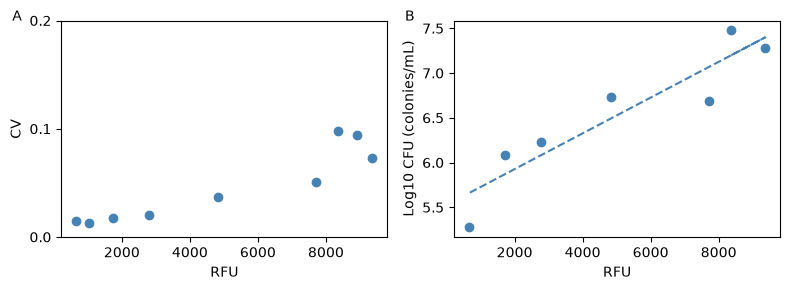

In [11]:
# calculate CV for ab and OD data

ab_cv = ab_std / ab_mean
od_cv = od_std / od_mean

cfu_hd_cv = cfu_hd_std / cfu_hd_mean

fig,ax_list = plt.subplots(figsize=(8,3),ncols=2)
ax = ax_list[0]
dilutions = np.arange(1, len(ab_cv)+1)

ax.scatter(ab_mean, ab_cv, color='steelblue', label='Fluorescence (RFU)')

ax.set_ylim([0,0.2])

ax.set_yticks([0,0.1,0.2])

ax.set_ylabel('CV')
ax.set_xlabel('RFU')

ax.annotate('A',xy=[-0.15,1],xycoords='axes fraction',fontsize=10)

ax = ax_list[1]
ax.scatter(ab_plot, np.log10(cfu_est), label='Data', color='steelblue')

# ax.set_yscale('log')

# fit a linear regression to the ab_plot vs cfu_est data

reg = LinearRegression().fit(np.array(ab_plot).reshape(-1,1), np.log10(np.array(cfu_est)).reshape(-1,1))

y_pred = reg.predict(np.array(ab_plot).reshape(-1,1)).flatten()

ax.plot(ab_plot, y_pred, label='Linear Fit', color='steelblue', linestyle='--')

# plot residuals as vertical lines from the data points to the regression line
residuals = np.log10(np.array(cfu_est)) - np.log10(y_pred)
# ax.vlines(ab_mean, y_pred, cfu_hd_mean, color='gray', alpha=0.5)

bias = np.abs(residuals) / np.log10(y_pred)

llq = ab_plot[np.argwhere(bias > 0.05)[0][0]-1]

# recompute regression with values excluding < llq
ab_mean_t = np.array(ab_plot)[np.array(ab_plot) >= llq]

cfu_mean_t = np.array(cfu_est)[np.array(ab_plot) >= llq]

reg = LinearRegression().fit(ab_mean_t.reshape(-1,1), np.log10(cfu_mean_t).reshape(-1,1))

y_pred = 10**reg.predict(ab_mean_t.reshape(-1,1)).flatten()

# ax.plot(ab_mean_t, y_pred, label='Linear Fit', color='orangered', linestyle='--')

ax.set_ylabel('Log10 CFU (colonies/mL)')
ax.set_xlabel('RFU')

ax.annotate('B',xy=[-0.15,1],xycoords='axes fraction',fontsize=10)

plt.tight_layout()

fig.savefig('../../figures/saureus_calibration_08292026.tiff',
            bbox_inches='tight',dpi=300)

In [12]:
# low density analysis
# SA are in rows E-G

ld_ab_file = '../calibration_data/cfu_assay_8312026/JC_FLUO_96w_20260829_111028_LWRB.xlsx'

p_ab = AutoRate.Plate(ld_ab_file,mode='single_measurement')
lb_ab = p_ab.od_data_to_dict(p_ab.data)

rows = ['E','F','G']
cols = ['2','3','4','5','6','7']

ab_background = np.mean([lb_ab[r+'8'] for r in rows])
ab_bg_est = np.mean([lb_ab[r+'8'] for r in rows])
ab_bg_std = np.std([lb_ab[r+'8'] for r in rows])
ab_bg_mean = np.mean([lb_ab[r+'8'] for r in rows])

ab_mean = []
ab_err = []
ab_std = []

# subtract ab_background from all values in ab_data
# lb_ab = {k: v - ab_background for k, v in lb_ab.items()}

for col in cols:
    ab_mean.append(np.mean([lb_ab[r+col] for r in rows]))
    ab_err.append(np.std([lb_ab[r+col] for r in rows])/np.sqrt(len(rows)))
    ab_std.append(np.std([lb_ab[r+col] for r in rows]))
    
# ab_mean = np.array(ab_mean) - ab_background

ab_mean = np.array(ab_mean)
ab_err = np.array(ab_err)
ab_std = np.array(ab_std)

# for each column, perform a t-test against the background

p_values = []

for col in cols:
    ab_values = [lb_ab[r+col] for r in rows]
    bg_values = [lb_ab[r+'8'] for r in rows]
    t_stat, p_val = stats.ttest_ind(ab_values, bg_values)
    p_values.append(p_val)

p_values = np.array(p_values)
# determine llq as the highest column where the p-value is above 0.05
llq = None
for col, p_val in zip(cols, p_values):
    print(p_val)
    if p_val > 0.05:
        llq = col
        llq_val = ab_mean[cols.index(col)]
        break

print(f'LLQ: col {llq}')

2.756882756748137e-08
1.414658192103872e-05
0.00039475664977221874
0.28109198416185777
LLQ: col 5


In [13]:
cfu_lwrb['dilution_factor'] = cfu_lwrb['subsequent_dilution'] / cfu_lwrb['vol']
cfu_lwrb['B_raw_counts'] = cfu_lwrb['B']
cfu_lwrb['C_raw_counts'] = cfu_lwrb['C']
cfu_lwrb['B'] = cfu_lwrb['B'] * cfu_lwrb['dilution_factor']
cfu_lwrb['C'] = cfu_lwrb['C'] * cfu_lwrb['dilution_factor']
cfu_lwrb['mean'] = cfu_lwrb[['B','C']].mean(axis=1)

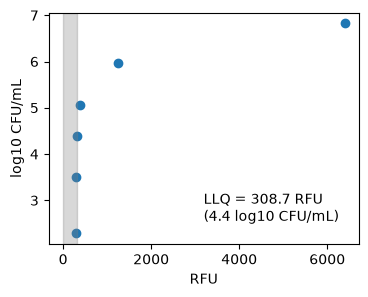

In [14]:
fig,ax = plt.subplots(figsize=(4,3))

ax.scatter(ab_mean, np.log10(cfu_lwrb['mean']))

# ax.set_yscale('log')

# shade the axis from 0 to llq

xlim = ax.get_xlim()

ax.axvspan(xlim[0], llq_val, color='gray', alpha=0.3)

ax.set_xlabel('RFU')
ax.set_ylabel('log10 CFU/mL')

# llq_cfu = np.log10(cfu_lwrb['mean'][cols.index(llq)])
# cfu_str = '(' + str(np.round(llq_cfu,1)) + ' log10 CFU)'
# ax.annotate('LLQ: ' + str(np.round(llq_val,1)) + ' RFU ' + cfu_str, xy=(0.2, 0.1), xycoords='axes fraction')

llq_cfu = np.log10(cfu_lwrb['mean'][cols.index(llq)])
cfu_str = '\n(' + str(np.round(llq_cfu,1)) + ' log10 CFU/mL)'
ax.annotate('LLQ = ' + str(np.round(llq_val,1)) + ' RFU ' + cfu_str, xy=(0.5, 0.1), xycoords='axes fraction')

fig.savefig('../../figures/SA_llq.tiff',bbox_inches='tight',dpi=300)

In [15]:
with open('../calibration_data/calibration_Saureus_08292026.pkl','wb') as f:
    pickle.dump({'reg': reg, 'background': ab_background,
                 'ulq': ulq,
                 'llq': llq}, f)